# Car Price Prediction — EDA & Modeling

**Goal:** Predict the resale price of a used car from its listed attributes
(age, mileage, engine size, fuel type, transmission, etc.)

**Dataset:** [Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)
— used-car listings scraped from CarDekho.com (India).

This notebook covers data loading, cleaning, feature engineering, and EDA,
followed by model training and evaluation.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from clean_data import load_raw, clean

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Loading the raw data

In [2]:
df_raw = load_raw("../data/raw/car_details_v3.csv")
print(df_raw.shape)
df_raw.head()

(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 2. Initial inspection

Before cleaning, it helps to check for two things: missing values, and
duplicate rows.

Several columns (`mileage`, `engine`, `max_power`, `torque`) are stored as
text with units baked in (e.g. `"23.4 kmpl"`), so they need parsing before
they're usable.

In [3]:
df_raw.info()
print("\nMissing values:\n", df_raw.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB

Missing values:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0


**An important finding:** checking for exact duplicate rows (the same car
listing repeated, with every column identical) turns up a large number of
them.

In [4]:
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("That's about", round(df_raw.duplicated().sum() / len(df_raw) * 100, 1), "% of the dataset.")

Exact duplicate rows: 1202
That's about 14.8 % of the dataset.


This matters more than it might seem. If the same row appears twice, one
copy can end up in the training data and the other copy in the test data.
The model would then be "tested" on a car it had already memorized
word-for-word during training — making it look more accurate than it
actually is on genuinely new cars. These duplicates are removed as part
of cleaning, below.

## 3. Cleaning and feature engineering

The steps applied here (in `src/clean_data.py`):
- Exact duplicate rows are removed, for the reason explained above.
- Units are stripped from `mileage`, `engine`, `max_power` and converted to float.
- `brand` is extracted from the free-text `name` column.
- `car_age` is engineered from `year` (more directly useful than a raw year value).
- `owner` is converted to an ordinal `owner_num`, where a lower number
  means fewer previous owners.

**What's deliberately *not* done here:** filling in missing numbers and
capping extreme outliers. Earlier versions of this project did both of
these on the whole dataset before splitting into train/test. That's a
subtle form of data leakage — the "median" or "cutoff" values would have
been calculated using information from the test set too, which the model
isn't supposed to see. Both are now done later, inside the model pipeline,
using only the training data.

In [5]:
df = clean(df_raw)
print(df.shape)
df.head()

(6926, 14)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,car_age,owner_num
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,Maruti,12,1
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,Skoda,12,2
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,Honda,20,3
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,Hyundai,16,1
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,Maruti,19,1


In [6]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
seats            208
mileage_kmpl     208
engine_cc        208
max_power_bhp    206
brand              0
car_age            0
owner_num          0
dtype: int64

## 4. Exploratory data analysis

### 4.1 Target distribution

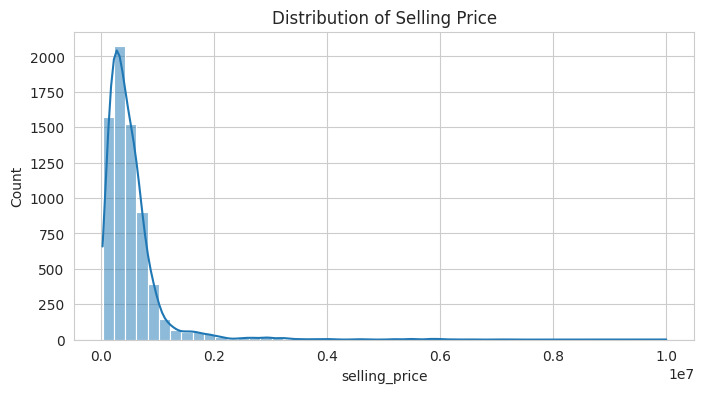

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df["selling_price"], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.show()

Selling price is right-skewed: most cars are priced toward the lower end,
with a long tail of much more expensive vehicles. This is typical for a
used-car market, where budget and economy cars are far more common than
luxury ones.

### 4.2 Price vs. key numeric features

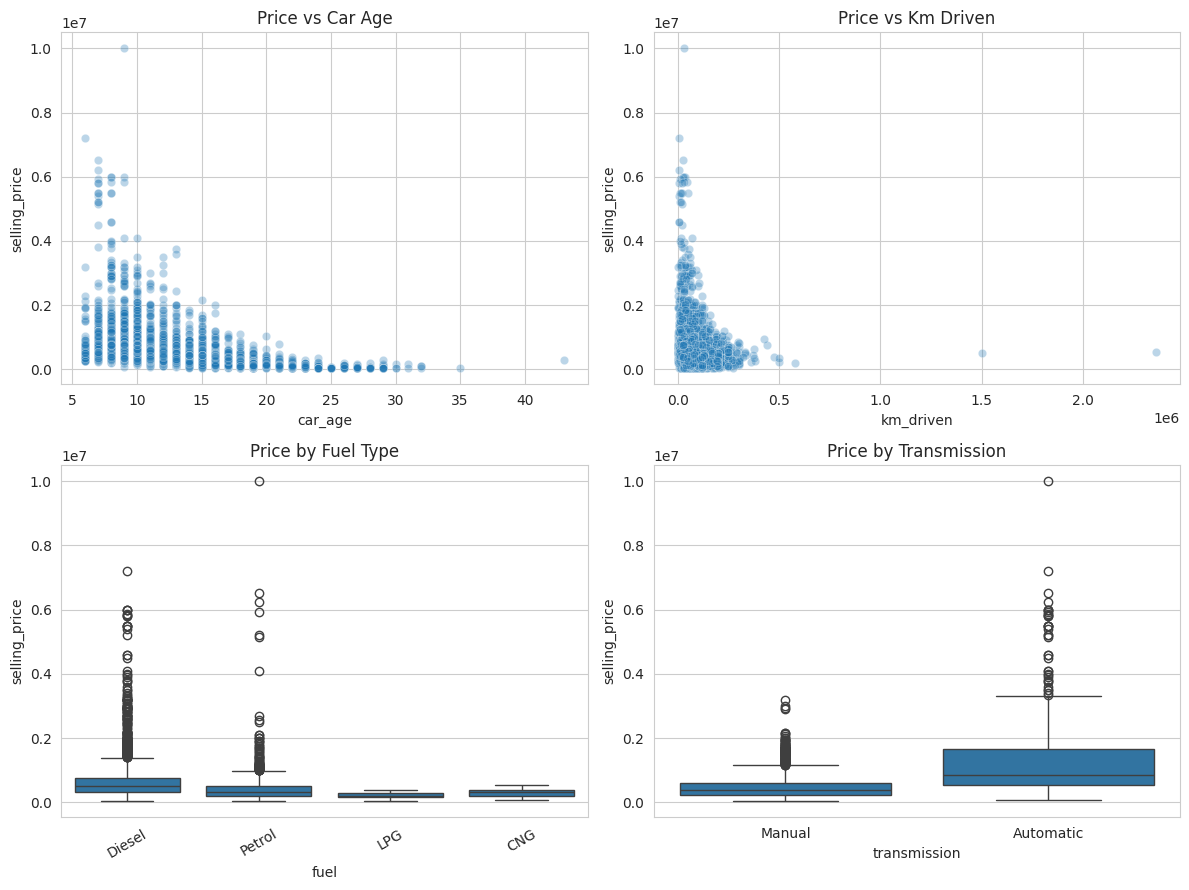

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title("Price vs Car Age")

sns.scatterplot(data=df, x="km_driven", y="selling_price", alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title("Price vs Km Driven")

sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Price by Fuel Type")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Price by Transmission")

plt.tight_layout()
plt.savefig("../visuals/eda_overview.png", dpi=120)
plt.show()

**Observations:**
- Price drops fast during a car's first ~10 years, then the drop slows
  down , age matters a lot for newer cars, less so for older ones.
- Price vs. km driven shows a weaker, noisier negative trend than age does.
- Diesel cars have a higher median price than petrol, LPG, or CNG cars.
- Automatic-transmission cars sell for noticeably more than manual ones.

### 4.3 Correlation heatmap (numeric features)

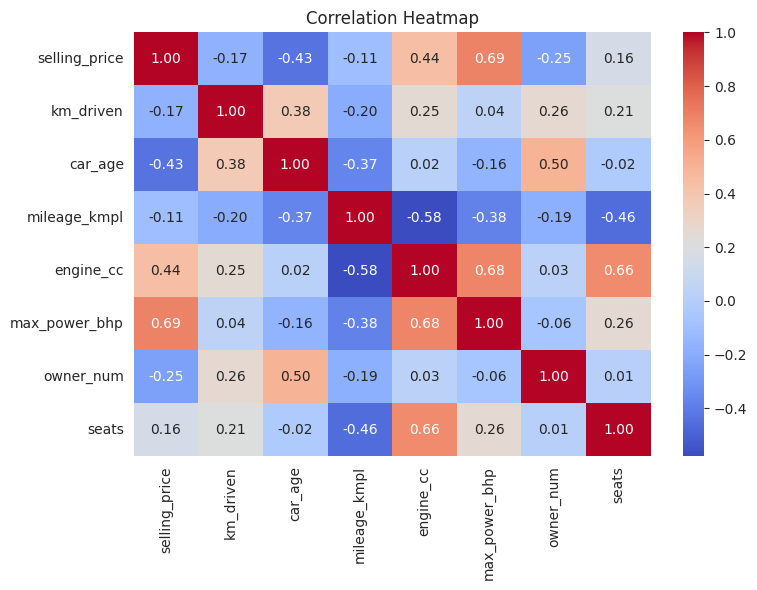

In [9]:
plt.figure(figsize=(8, 6))
numeric_cols = ["selling_price", "km_driven", "car_age", "mileage_kmpl",
                 "engine_cc", "max_power_bhp", "owner_num", "seats"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../visuals/correlation_heatmap.png", dpi=120)
plt.show()

`max_power_bhp` and `engine_cc` are the strongest positive correlates of
price; `car_age` is the strongest negative correlate. `km_driven` has a
moderate negative correlation-real, but weaker than age. `mileage_kmpl`
(fuel efficiency) has only a weak negative correlation with price, since
fuel-efficient cars mostly cluster in the cheaper, economy segment rather
than driving price down directly.

### 4.4 A categorical relationship worth checking: seller type

In [10]:
print(df.groupby("seller_type")["selling_price"].median().sort_values(ascending=False))

seller_type
Trustmark Dealer    650000.0
Dealer              620000.0
Individual          390000.0
Name: selling_price, dtype: float64


Dealer listings have a noticeably higher median price than individual
sellers, with "Trustmark Dealer" close behind. This likely reflects that
dealers often recondition cars and may offer warranties, which individual
sellers typically don't.

## 5. Exporting the cleaned dataset

In [11]:
df.to_csv("../data/processed/car_clean.csv", index=False)
print("Cleaned dataset exported.")

Cleaned dataset exported.


---
## 6. Modeling

Three models of increasing complexity are compared:
- **Linear Regression** — simple baseline, assumes linear relationships.
- **Random Forest** — an ensemble of decision trees, captures non-linear
  patterns (like price flattening out after ~10 years of age).
- **Gradient Boosting** — sequentially corrects errors, often very accurate
  but slower to train.

Categorical features (`brand`, `fuel`, `seller_type`, `transmission`) are
one-hot encoded. Missing numeric values are filled in using the median —
but this time, that median is calculated using **only the training data**,
inside the pipeline, so no information from the test set leaks in. This is
the leak-free fix explained in section 3.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

NUMERIC_FEATURES = ["car_age", "km_driven", "mileage_kmpl", "engine_cc",
                     "max_power_bhp", "seats", "owner_num"]
CATEGORICAL_FEATURES = ["brand", "fuel", "seller_type", "transmission"]
TARGET = "selling_price"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5540, 11), Test: (1386, 11)


### 6.1 Preprocessing and model pipeline

In [13]:
def build_pipeline(model):
    num_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    preprocessor = ColumnTransformer(transformers=[
        ("num", num_transformer, NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42),
}

### 6.2 Training and evaluating all three models

In [14]:
results = []
fitted = {}

for name, model in candidates.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

,model,rmse,mae,r2
0,Gradient Boosting,117694.755876,72034.989957,0.936841
1,Random Forest,127042.973512,72181.883010,0.926410
2,Linear Regression,300052.354745,168911.138793,0.589501


### 6.3 Selecting the best model

Gradient Boosting comes out ahead this time — it's carried forward as the
final model.

**Why the scores here are lower than an earlier version of this project:**
an earlier version of this pipeline had two problems: duplicate rows were
never removed, and the missing-value/outlier handling was calculated on
the full dataset before splitting into train and test. Testing each fix
separately showed that removing the duplicate rows was responsible for
almost the entire drop in score — since duplicated cars could appear in
both the training and test sets, letting the model be "tested" on
something it had already memorized. The leak-free imputation fix, on its
own, barely changed the score at all. A lower score that reflects a
correct, leak-free setup is more trustworthy than a higher score that
doesn't.

In [15]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted[best_name]
print(f"Best model: {best_name}")

Best model: Gradient Boosting


### 6.4 Feature importance

For the winning tree-based model, this shows which features drove its
predictions the most.

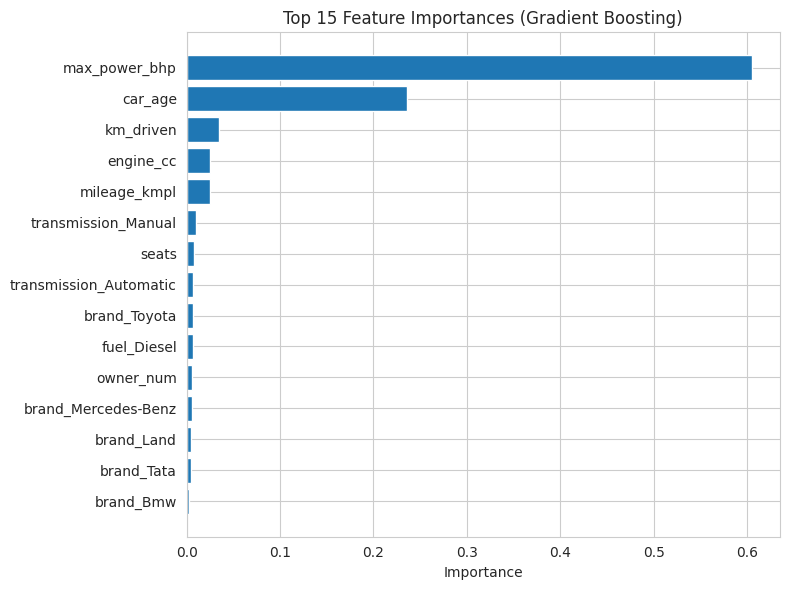

In [16]:
if best_name in ("Random Forest", "Gradient Boosting"):
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
    all_names = NUMERIC_FEATURES + list(cat_names)

    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": all_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(f"Top 15 Feature Importances ({best_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../visuals/feature_importance.png", dpi=120)
    plt.show()

`max_power_bhp` and `car_age` dominate — consistent with the correlation
heatmap from the EDA section. This agreement between EDA and the trained
model's feature importance is a good sanity check that the model learned
something real, not noise.

### 6.5 Predicted vs. actual price

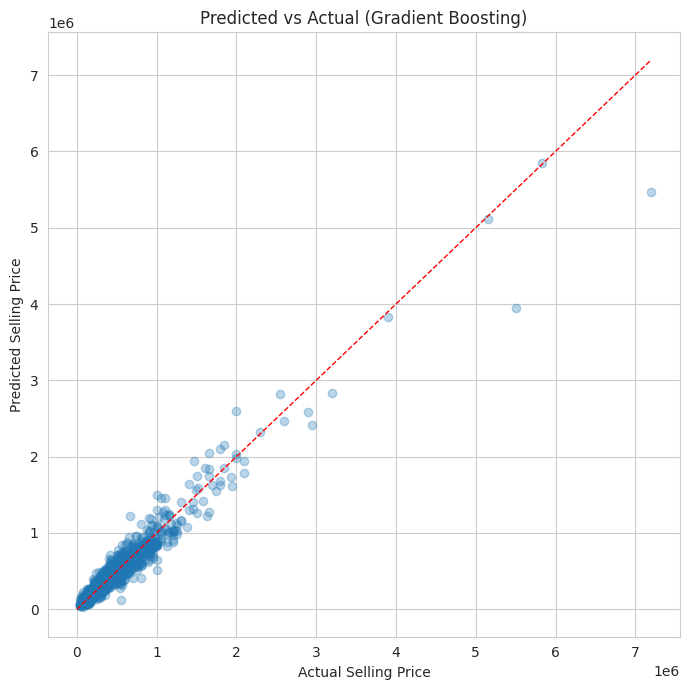

In [17]:
preds = best_pipe.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.3)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Predicted vs Actual ({best_name})")
plt.tight_layout()
plt.savefig("../visuals/predicted_vs_actual.png", dpi=120)
plt.show()

Points cluster along the diagonal across the full price range, with
errors scattered on both sides of the line rather than consistently
leaning high or low. Since these test cars were never seen during
training, and are no longer duplicated anywhere in the training data
either, this is a fair, honest check: it confirms the model learned a
real, general pattern rather than memorizing specific listings.

### 6.6 Exporting the final model

In [18]:
import joblib
joblib.dump(best_pipe, "../models/best_model.pkl")
results_df.to_csv("../models/results.csv", index=False)
print("Best model and results table exported.")

Best model and results table exported.


## Conclusion

- After removing 1,202 exact duplicate rows (about 15% of the dataset)
  and fixing a data leakage issue in how missing values were filled in,
  the model's R² dropped from an earlier, inflated 0.975 to a more honest
  0.937. Almost all of that drop came from removing the duplicates, not
  from the leakage fix — testing each change separately confirmed this.
- Gradient Boosting is now the best model (R²=0.937), narrowly ahead of
  Random Forest (R²=0.926). Both far outperform Linear Regression
  (R²=0.590), confirming the price/age relationship is non-linear.
- `max_power_bhp` and `car_age` remain by far the strongest predictors,
  consistent with both the correlation heatmap and the earlier version
  of this model.
- This performance is measured on the 20% of cars the model never saw
  during training, with no duplicate cars leaking between the two sets —
  a fair test of whether the model learned a real, general pattern.
- The remaining unexplained variation likely reflects real-world factors
  not captured in this dataset (negotiation, cosmetic condition, urgency
  of sale), rather than a flaw in the model itself.
- The saved `models/best_model.pkl` can be loaded directly for inference
  without retraining: `joblib.load("models/best_model.pkl")`.

**A note on scope:** this model only reflects the Indian used-car market
it was trained on — brand availability, import taxes, and buyer
preferences differ significantly by country. Currency conversions shown
alongside predictions (in `predict.py` / `app.py`) are simple unit
conversions of the Indian price, not predictions of what an equivalent
car would actually sell for in another country's market. A model trained
on that market's own data would be needed for that.